In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

import joblib

In [4]:
df = pd.read_csv("Country-data.csv")
dictionary = pd.read_csv("data-dictionary.csv")

print(df.head())

print(dictionary)

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  
  Column Name                                        Description
0     country                                Name of the country
1  child_mort  Death of children under 5 years of age per 100...
2     exports  Exports of goods and services per capita. Give...
3      health  Total health spending 

In [5]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.columns)

print(df.isnull().sum())

print(df.duplicated().sum())

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.81

In [6]:
df = df.drop_duplicates()

df = df.dropna()

print(df.shape)

(167, 10)


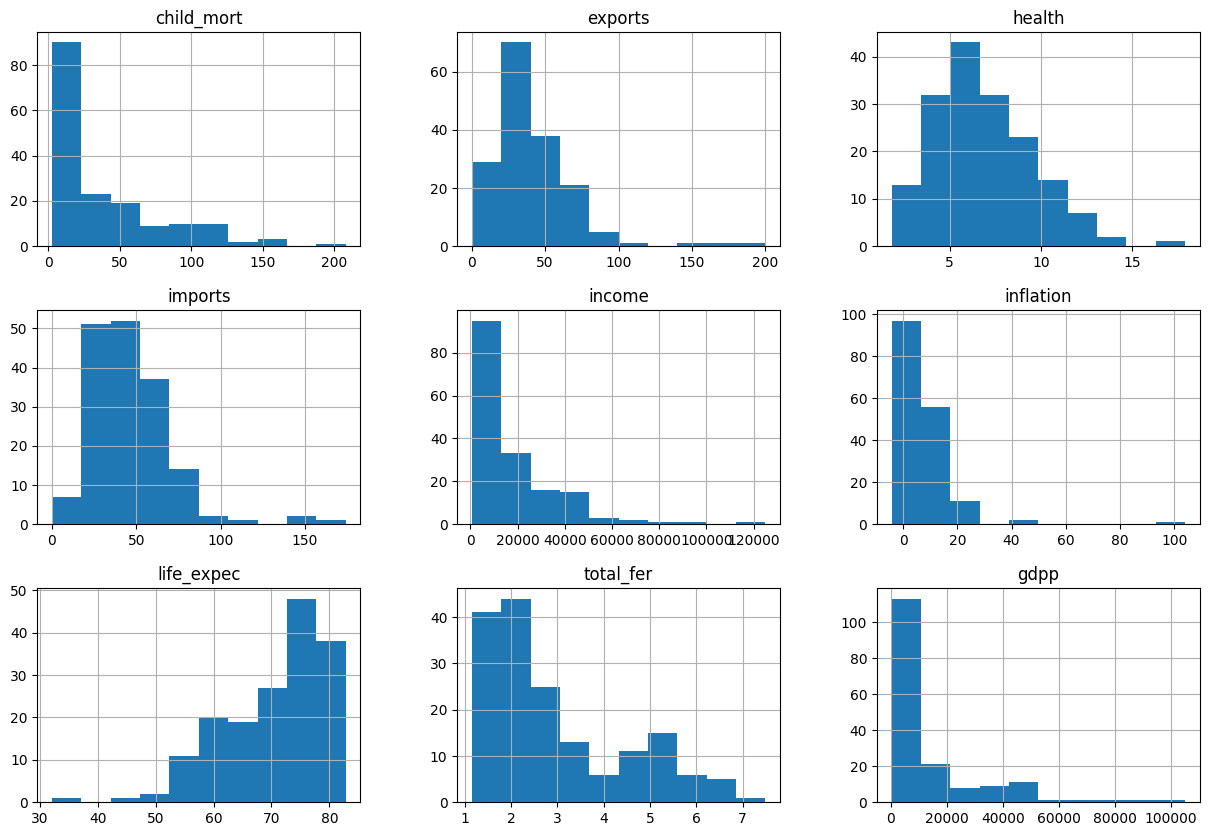

In [7]:
df.hist(figsize=(15,10))

plt.show()

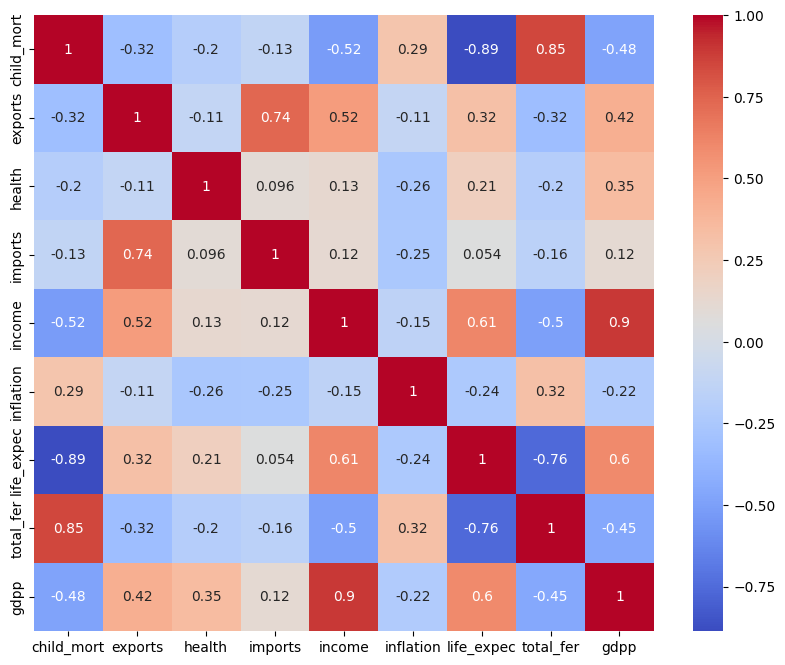

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(df.drop("country",axis=1).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

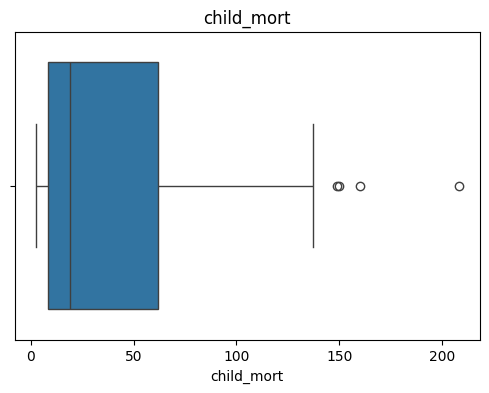

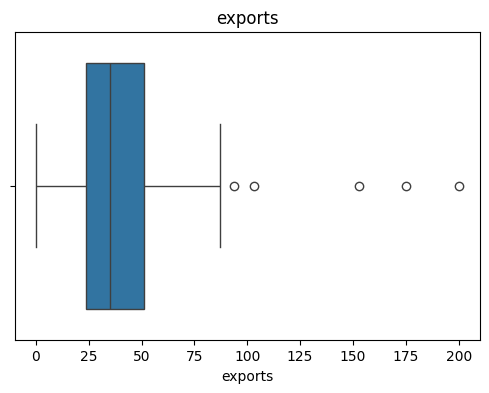

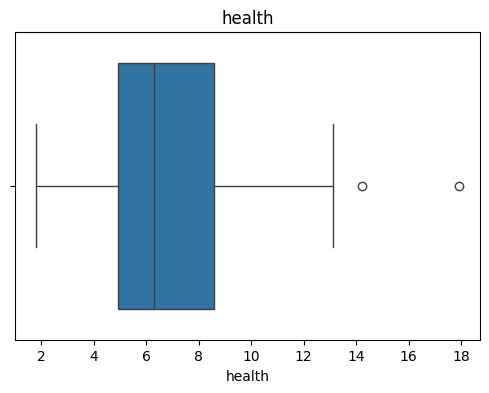

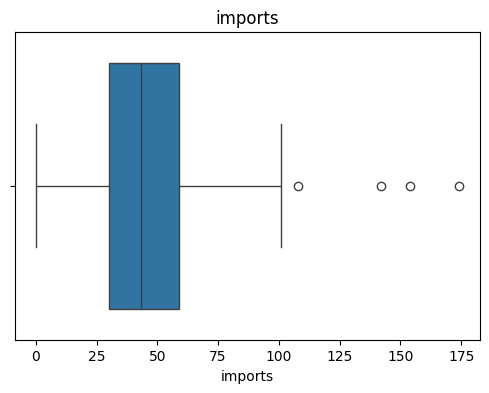

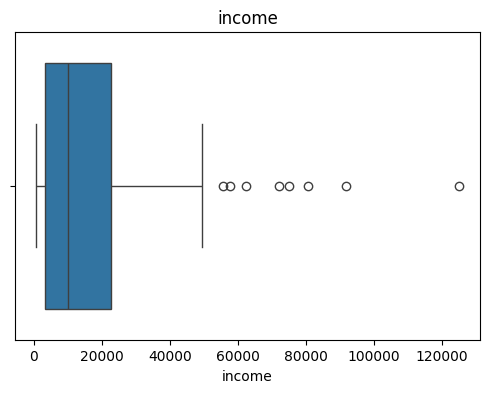

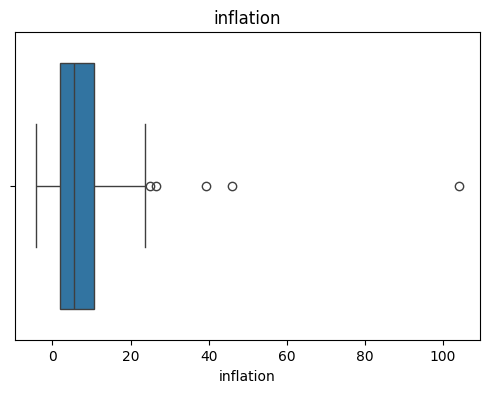

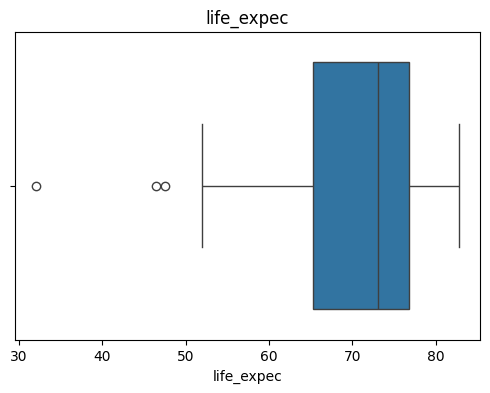

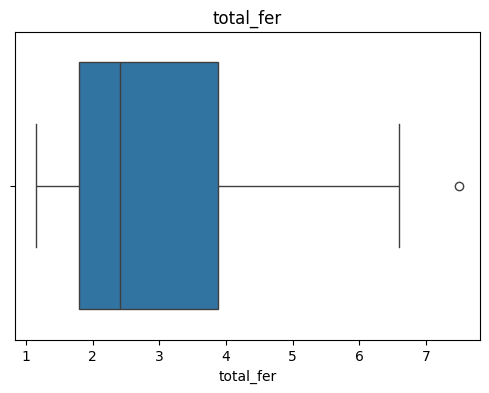

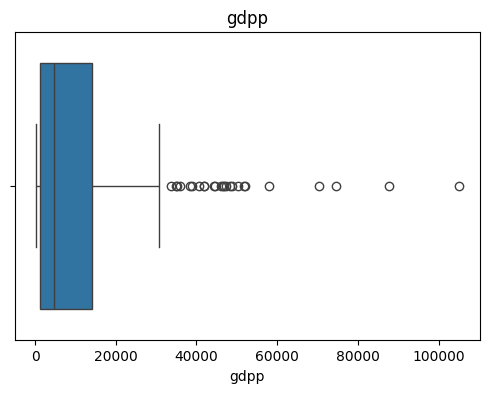

In [9]:
columns = df.columns[1:]

for col in columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [10]:
X = df.drop("country",axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


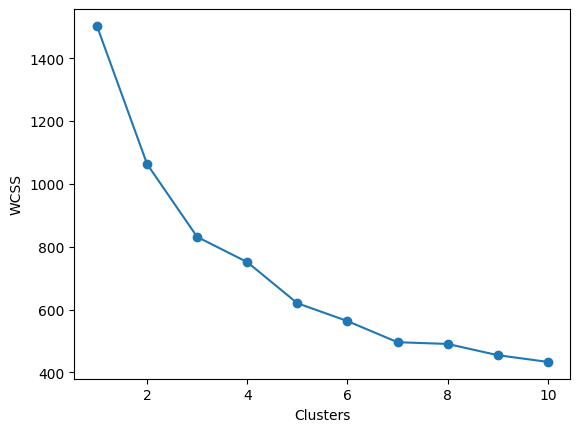

In [13]:
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i,
                   random_state=42)

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

In [14]:
kmeans = KMeans(n_clusters=3,
                random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(df.head())

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  Cluster  
0       9.44        56.2       5.82    553        2  
1       4.49        76.3       1.65   4090        0  
2      16.10        76.5       2.89   4460        0  
3      22.40        60.1       6.16   3530        2  
4       1.44        76.8       2.13  12200        0  


In [15]:
score = silhouette_score(X_scaled,clusters)

print(score)

0.285600988953231


In [16]:
dbscan = DBSCAN(eps=1.5,
                min_samples=5)

db_clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN"] = db_clusters

print(df["DBSCAN"].value_counts())

DBSCAN
 0    137
-1     30
Name: count, dtype: int64


In [17]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca,
                      columns=["PC1","PC2"])

pca_df["Cluster"] = clusters

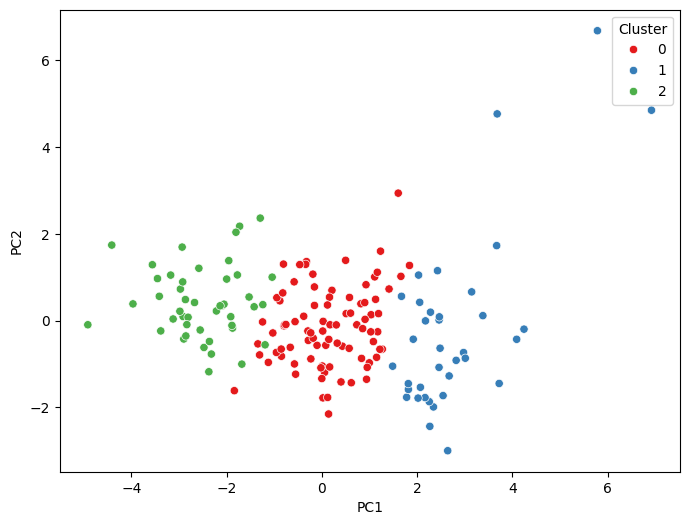

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=pca_df,
                x="PC1",
                y="PC2",
                hue="Cluster",
                palette="Set1")

plt.show()

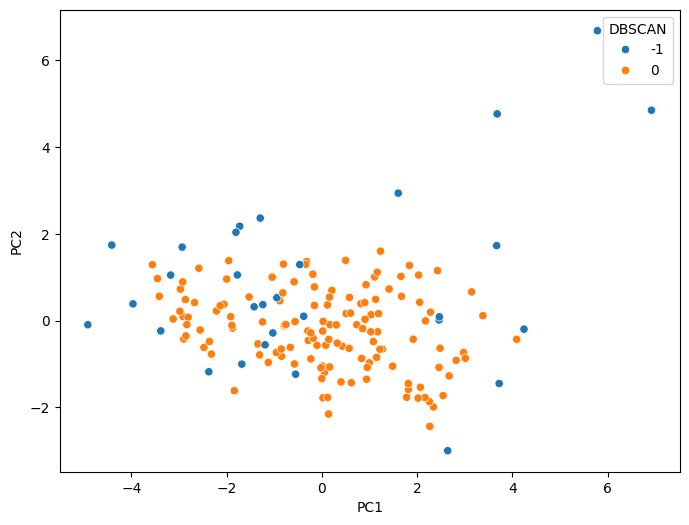

In [19]:
pca_df["DBSCAN"] = db_clusters

plt.figure(figsize=(8,6))

sns.scatterplot(data=pca_df,
                x="PC1",
                y="PC2",
                hue="DBSCAN",
                palette="tab10")

plt.show()

In [20]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

print(cluster_summary)

         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0         22.456977  40.273128  6.251047  47.362394  12321.744186   7.720884   
1          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
2         95.106667  28.602444  6.301111  42.306667   3539.844444  11.986778   

         life_expec  total_fer          gdpp    DBSCAN  
Cluster                                                 
0         72.566279   2.340349   6461.767442 -0.069767  
1         80.127778   1.752778  42494.444444 -0.250000  
2         59.055556   5.065333   1766.711111 -0.333333  


In [21]:
high_income = df[df["Cluster"]==0]

print(high_income["country"])

1                  Albania
2                  Algeria
4      Antigua and Barbuda
5                Argentina
6                  Armenia
              ...         
160                Uruguay
161             Uzbekistan
162                Vanuatu
163              Venezuela
164                Vietnam
Name: country, Length: 86, dtype: object


In [22]:
medium_income = df[df["Cluster"]==1]

print(medium_income["country"])

7                 Australia
8                   Austria
11                  Bahrain
15                  Belgium
23                   Brunei
29                   Canada
42                   Cyprus
43           Czech Republic
44                  Denmark
53                  Finland
54                   France
58                  Germany
60                   Greece
68                  Iceland
73                  Ireland
74                   Israel
75                    Italy
77                    Japan
82                   Kuwait
91               Luxembourg
98                    Malta
110             Netherlands
111             New Zealand
114                  Norway
122                Portugal
123                   Qatar
133               Singapore
134         Slovak Republic
135                Slovenia
138             South Korea
139                   Spain
144                  Sweden
145             Switzerland
157    United Arab Emirates
158          United Kingdom
159           United

In [23]:
low_income = df[df["Cluster"]==2]

print(low_income["country"])

0                   Afghanistan
3                        Angola
17                        Benin
25                 Burkina Faso
26                      Burundi
28                     Cameroon
31     Central African Republic
32                         Chad
36                      Comoros
37             Congo, Dem. Rep.
38                  Congo, Rep.
40                Cote d'Ivoire
49            Equatorial Guinea
50                      Eritrea
55                        Gabon
56                       Gambia
59                        Ghana
63                       Guinea
64                Guinea-Bissau
66                        Haiti
80                        Kenya
81                     Kiribati
84                          Lao
87                      Lesotho
88                      Liberia
93                   Madagascar
94                       Malawi
97                         Mali
99                   Mauritania
106                  Mozambique
108                     Namibia
112     

In [24]:
joblib.dump(kmeans,"kmeans_model.pkl")

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']